# Minimierung des Makespan in einem Job-Shop mit PROC OPTMODEL


## Zusammenfassung

Eine kleine Zelle der diskreten Fertigung muss vier Teile — einen **Bracket**, einen **Flange**, ein **Housing** und einen **Shaft** — durch eine feste Abfolge von jeweils drei Bearbeitungsoperationen schleusen und teilt sich dabei vier Maschinen mit Einzelkapazität (**Saw**, **Mill**, **Drill**, **Grind**). Keine Maschine kann zwei Operationen gleichzeitig ausführen, und die Operationen jedes Teils müssen ihrer technologischen Reihenfolge folgen. Wir formulieren den Makespan-minimierenden Ablaufplan als gemischt-ganzzahliges Programm in **PROC OPTMODEL** — Startzeitvariablen, Ende-zu-Start-Vorrangbedingungen und disjunktive (Big-*M*-)Überschneidungsverbots-Bedingungen zwischen jedem Paar von Operationen, die sich eine Maschine teilen — und lösen ihn bis zur bewiesenen Optimalität.

Der MILP-Solver liefert einen **optimalen Makespan von 120 Minuten** (`Solution Status = Optimal`, `Objective Value = 120`). Der resultierende Ablaufplan packt alle zwölf Operationen so, dass jede Maschine höchstens ein Teil gleichzeitig bearbeitet und jedes Teil in seiner geforderten Reihenfolge Saw/Mill/Drill vor Grind bearbeitet wird. Zwei Operationen enden genau bei Minute 120 — das Schleifen des Bracket und das Fräsen des Housing —, sodass sowohl die Grind- als auch die Mill-Maschine auf dem kritischen Pfad liegen, der die Ablaufplanlänge festlegt.

## Datenquellen

Alle Daten werden im Notebook definiert — keine externen Dateien oder Netzwerk.

| Datenmenge | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Eine Zeile je Operation (4 Teile × 3 Operationen). `machine` (1–4) ist die von der Operation benötigte Maschine; `dur` ist ihre Bearbeitungszeit in Minuten; `jobname`/`mname` sind lesbare Teil- und Maschinenbezeichnungen. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL-Ausgabe: die optimale Start- und Endminute jeder Operation. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` mit den gelösten Zeiten zusammengeführt, sortiert nach Maschine, dann Start — der menschenlesbare Ablaufplan. |
| `mk` | 1 | `makespan` | Der realisierte Makespan (späteste Endzeit). |

## Das Ablaufplanungsproblem

In einer **Werkstattfertigung** (Job-Shop) durchläuft jedes von mehreren Teilen ("Jobs") eine feste Abfolge von Operationen, und jede Operation läuft auf einer bestimmten Maschine. Zwei Operationen können nicht gleichzeitig dieselbe Maschine belegen (die Maschinen sind *unäre* Ressourcen), und innerhalb eines Teils müssen die Operationen ihre technologische Reihenfolge einhalten. Der Planer möchte für jede Operation Startzeiten, die beide Regeln einhalten und zugleich die gesamte Ablaufplanlänge — den **Makespan** — so klein wie möglich halten.

Dies ist ein klassisches disjunktives Ablaufplanungsproblem. Wir modellieren es als gemischt-ganzzahliges Programm:

- eine kontinuierliche, aber ganzzahlige **Startzeit** `s[o]` für jede Operation und eine Makespan-Variable `Cmax`;
- **Vorrang**: Operation *k+1* eines Teils startet nicht früher, als Operation *k* endet;
- **disjunktive Maschinenkapazität**: Für jedes Paar von Operationen, die sich eine Maschine teilen, entscheidet ein binäres `y`, welche zuerst kommt, und ein Big-*M*-Term schaltet die inaktive Reihenfolge ab — sodass sich die beiden Operationen niemals überschneiden können;
- **Zielfunktion**: Minimierung von `Cmax`, das gezwungen wird, mindestens die Endzeit jeder Operation zu sein.

PROC OPTMODEL ist die algebraische Modellierungsprozedur von SAS/OR; ihr MILP-Solver findet den *nachweislich optimalen* kürzesten Ablaufplan.

> **Ein Hinweis zu PROC CLP.** SAS bietet auch PROC CLP, eine Constraint-Logik-Programmierungs-Engine mit dedizierter Ablaufplanungssyntax (Aktivitäten, Ressourcen, Vorrang). Die hier verwendete OPTMODEL-MILP-Formulierung löst das identische Problem und liefert ein Optimalitätszertifikat, was die Zulässigkeitssuche von CLP nicht tut.

## Schritt 1 — Definition der Werkstattinstanz

Vier Teile, jeweils drei Operationen, auf vier Maschinen. Jede Zeile legt die von einer Operation benötigte Maschine und ihre Bearbeitungszeit in Minuten fest. Die Operationen eines Teils sind in technologischer Reihenfolge aufgeführt (`opnum` 1, 2, 3).

In [1]:
DATEN jobshop;
    LÄNGE jobname $10 mname $6;
    EINGABE op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Bracket  Saw
2  1 2 3 40 Bracket  Drill
3  1 3 4 20 Bracket  Grind
4  2 1 2 35 Flange   Mill
5  2 2 3 25 Flange   Drill
6  2 3 1 15 Flange   Saw
7  3 1 3 30 Housing  Drill
8  3 2 1 20 Housing  Saw
9  3 3 2 45 Housing  Mill
10 4 1 1 20 Shaft    Saw
11 4 2 2 30 Shaft    Mill
12 4 3 4 25 Shaft    Grind
;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=jobshop noobs;
    TITEL 'Job-Shop Instance: 4 parts, 3 operations each, 4 machines';
    VAR op jobname opnum mname dur;
AUSFÜHREN;

                               Job-Shop Instance: 4 parts, 3 operations each, 4 machines                                

OP  JOBNAME  OPNUM  MNAME  DUR
 1  Bracket      1  Saw     25
 2  Bracket      2  Drill   40
 3  Bracket      3  Grind   20
 4  Flange       1  Mill    35
 5  Flange       2  Drill   25
 6  Flange       3  Saw     15
 7  Housing      1  Drill   30
 8  Housing      2  Saw     20
 9  Housing      3  Mill    45
10  Shaft        1  Saw     20
11  Shaft        2  Mill    30
12  Shaft        3  Grind   25



NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Schritt 2 — Lösung des Makespan-minimierenden Ablaufplans mit PROC OPTMODEL

OPTMODEL liest die Instanz ein, bildet die Startzeit- und Reihenfolgevariablen, stellt die Vorrang- und disjunktiven Bedingungen auf und minimiert den Makespan mit seinem MILP-Solver. Der Big-*M*-Horizont `H` ist der gesamte Arbeitsinhalt — eine sichere obere Schranke für jede Startzeit. Der Solver berichtet die **optimale** Zielfunktion; wir schreiben die gewählten Start- und Endzeiten nach `sched`.

In [2]:
PROZEDUR optmodel;
    FESTLEGEN OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DATEN jobshop INTO OPS=[op] job opnum machine dur;

    /* a safe big-M horizon = total work content */
    num H = sum{o in OPS} dur[o];

    VAR s{OPS} >= 0 integer;     /* operation start time (minutes) */
    VAR Cmax >= 0;               /* makespan */

    /* technological order: op k+1 starts after op k finishes */
    con prec{a in OPS, b in OPS:
             job[a] = job[b] UND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominates every operation's finish time */
    con span{o in OPS}: Cmax >= s[o] + dur[o];

    /* disjunctive machine capacity: for each operation pair sharing a
       machine, binary y fixes the order; big-M relaxes the other */
    VAR y{a in OPS, b in OPS:
          a < b UND machine[a] = machine[b]} binary;
    con seqAB{a in OPS, b in OPS:
              a < b UND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a in OPS, b in OPS:
              a < b UND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o in OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    ERSTELLEN DATEN sched VON
        [op]={o in OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                               Job-Shop Instance: 4 parts, 3 operations each, 4 machines                                


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000



NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Schritt 3 — Zusammenstellung des lesbaren Ablaufplans

Die gelösten Zeiten werden wieder mit den Teil- und Maschinenbezeichnungen zusammengeführt, nach Maschine, dann Startzeit sortiert, und der Ablaufplan wird ausgegeben. Der Makespan ist die größte Endzeit über alle Operationen hinweg.

In [3]:
PROZEDUR SORTIEREN DATEN=jobshop out=jobs2; NACH op; AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=sched   out=sol;   NACH op; AUSFÜHREN;

DATEN schedule;
    ZUSAMMENFÜHREN jobs2 sol;
    NACH op;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=schedule; NACH mname START; AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=schedule noobs;
    TITEL 'Optimal Schedule: start / finish (minutes) of every operation';
    VAR jobname opnum mname dur START FINISH;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=schedule MAX NOPRINT;
    VAR FINISH;
    AUSGABE out=mk(ENTFERNEN=_type_ _freq_) MAX=makespan;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=mk noobs;
    TITEL 'Minimum Makespan (latest operation finish, minutes)';
AUSFÜHREN;

                             Optimal Schedule: start / finish (minutes) of every operation                              

JOBNAME  OPNUM  MNAME  DUR  START  FINISH
Housing      1  Drill   30      0      30
Flange       2  Drill   25     35      60
Bracket      2  Drill   40     60     100
Shaft        3  Grind   25     65      90
Bracket      3  Grind   20    100     120
Flange       1  Mill    35      0      35
Shaft        2  Mill    30     35      65
Housing      3  Mill    45     75     120
Shaft        1  Saw     20      0      20
Bracket      1  Saw     25     20      45
Housing      2  Saw     20     45      65
Flange       3  Saw     15     65      80

                                  Minimum Makespan (latest operation finish, minutes)                                   

MAKESPAN
     120



NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset m

## Schritt 4 — Visualisierung des Ablaufplans

Wir geben jeder Operation einen ordinalen **Slot** (sortiert nach Maschine, dann Start) und zeichnen ihr Zeitfenster als schwebenden Balken: Der Balken reicht von der Startminute bis zur Endminute der Operation. Die Slots 1–3 sind der Drill, 4–5 der Grind, 6–8 der Mill und 9–12 der Saw. Die Tabelle direkt darunter benennt das Teil in jedem Slot, sodass Diagramm und Tabelle zusammen gelesen werden. Balken auf derselben Maschine überschneiden sich zeitlich nie — die sichtbar gemachte disjunktive Bedingung.

                                 Schedule by slot (slot order matches the chart below)                                  

SLOT  MNAME  JOBNAME  START  FINISH
   1  Drill  Housing      0      30
   2  Drill  Flange      35      60
   3  Drill  Bracket     60     100
   4  Grind  Shaft       65      90
   5  Grind  Bracket    100     120
   6  Mill   Flange       0      35
   7  Mill   Shaft       35      65
   8  Mill   Housing     75     120
   9  Saw    Shaft        0      20
  10  Saw    Bracket     20      45
  11  Saw    Housing     45      65
  12  Saw    Flange      65      80

                                 Schedule by slot (slot order matches the chart below)                                  



NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


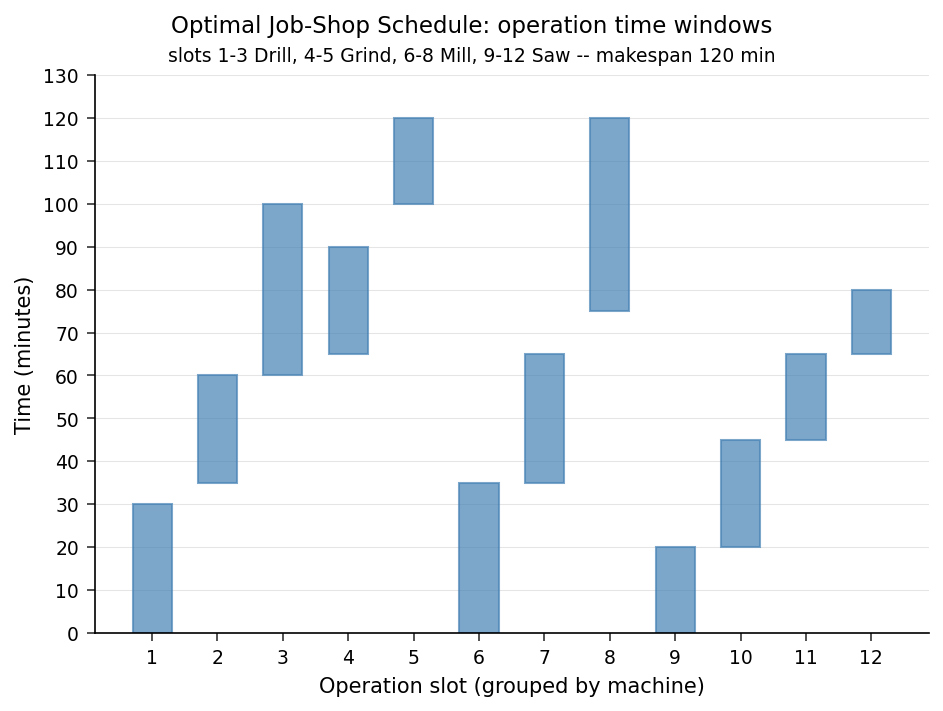

In [4]:
DATEN ganttdata;
    FESTLEGEN schedule;
    slot + 1;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=ganttdata noobs;
    TITEL 'Schedule by slot (slot order matches the chart below)';
    VAR slot mname jobname START FINISH;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=ganttdata noautolegend;
    TITEL 'Optimal Job-Shop Schedule: operation time windows';
    title2 'slots 1-3 Drill, 4-5 Grind, 6-8 Mill, 9-12 Saw -- makespan 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS BEZEICHNUNG='Operation slot (grouped by machine)' integer
          VALUES=(1 BIS 12 NACH 1);
    YAXIS BEZEICHNUNG='Time (minutes)' grid VALUES=(0 BIS 130 NACH 10);
AUSFÜHREN;
TITEL;

## Interpretation der Ergebnisse

- **Optimalität.** Der MILP-Solver lieferte `Solution Status = Optimal` mit `Objective Value = 120`, sodass **120 Minuten der nachweislich kürzestmögliche Makespan** für diese Instanz sind — kein Ablaufplan kann früher enden. Dieses Zertifikat ist das, was Ihnen die mathematische Programmierungsformulierung gegenüber einer reinen Zulässigkeitssuche verschafft.

- **Der Ablaufplan hält jede Bedingung ein.** Liest man die Tabelle nach Maschine, überschneiden sich keine zwei Operationen auf derselben Maschine (z. B. auf dem Saw: Shaft 0–20, Bracket 20–45, Housing 45–65, Flange 65–80), und jedes Teil läuft in technologischer Reihenfolge (z. B. Housing: Drill 0–30, dann Saw 45–65, dann Mill 75–120). Das Schwebebalken-Diagramm zeigt dasselbe: Innerhalb des Slot-Bandes jeder Maschine kacheln die Zeitfenster ohne Kollision.

- **Was die Ablaufplanlänge bestimmt.** Zwei Operationen enden genau bei Minute 120 — der Grind des Bracket (Slot 5) und der Mill des Housing (Slot 8). Beide berühren den Makespan, sodass die Grind- und die Mill-Maschine auf dem kritischen Pfad liegen; den Makespan weiter zu verkürzen würde erfordern, die Instanz selbst zu ändern (schnellere Operationen, eine zusätzliche Maschine oder gelockerten Vorrang), nicht bloß eine Neusequenzierung.

- **Wie es skaliert.** Die Formulierung wächst natürlich: Fügen Sie eine Maschine als weiteren Wert von `machine` hinzu, fügen Sie Teile als weitere Zeilen von `jobshop` hinzu oder modellieren Sie Freigabe- und Fälligkeitstermine, indem Sie `s[o]` beschränken und Fälligkeitsbedingungen hinzufügen. Einer Maschine zu erlauben, mehrere Jobs gleichzeitig auszuführen (Kapazität >1), ersetzt die paarweise Disjunktion durch eine kumulative Ressourcenbedingung. Dasselbe OPTMODEL-MILP behandelt dann reichhaltigere Werkstattregeln, ohne den Solver zu ändern.